In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Create visualizations folder if not exists
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')
    print("✅ 'visualizations' folder created!")

# Set style - FIXED version (using available styles)
try:
    # Try available styles
    available_styles = plt.style.available
    if 'seaborn-v0_8-darkgrid' in available_styles:
        plt.style.use('seaborn-v0_8-darkgrid')
    elif 'ggplot' in available_styles:
        plt.style.use('ggplot')
    else:
        plt.style.use('default')
    print("✅ Style applied successfully!")
except Exception as e:
    print(f"⚠️ Style error: {e}")
    print("✅ Using default style instead")

# Set color palette
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"📁 Visualizations folder: {'visualizations'}")

✅ Style applied successfully!
✅ Libraries imported successfully!
📁 Visualizations folder: visualizations


In [3]:
df = pd.read_excel('Cleaned_Dataset.xlsx')
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Loaded: 1200 rows, 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print("="*50)
print("BASIC STATISTICS")
print("="*50)
display(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe())

BASIC STATISTICS


,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


In [20]:
total_revenue = df['TotalPrice'].sum()
avg_order = df['TotalPrice'].mean()
total_orders = len(df)

print("="*50)
print("💰 KEY METRICS")
print("="*50)
print(f"Total Revenue:     ₹{total_revenue:,.2f}")
print(f"Average Order:     ₹{avg_order:,.2f}")
print(f"Total Orders:      {total_orders:,}")

💰 KEY METRICS
Total Revenue:     ₹1,264,761.96
Average Order:     ₹1,053.97
Total Orders:      1,200


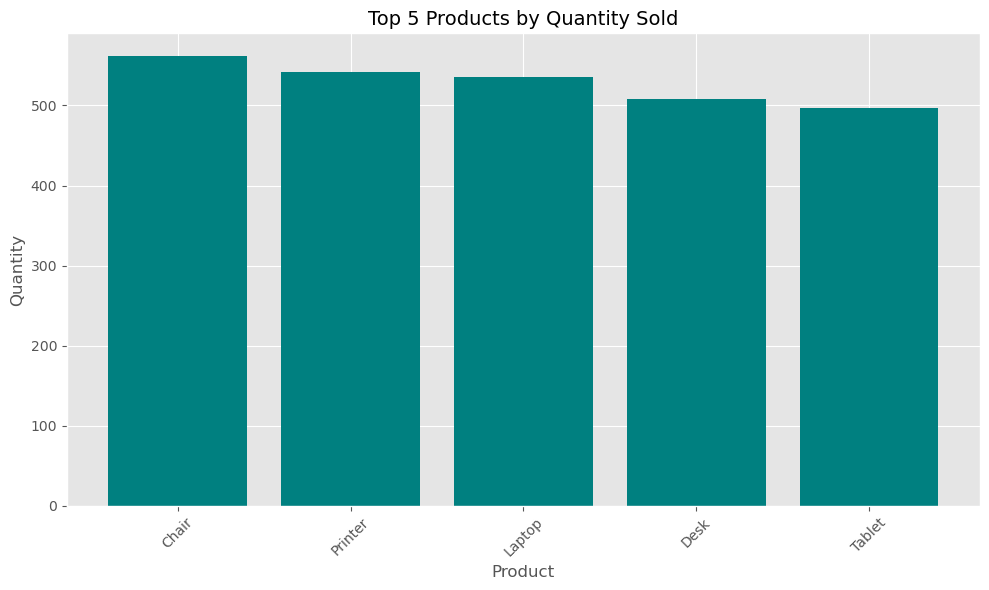

✅ Saved: visualizations/top_products_qty.png


In [7]:
product_qty = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.bar(product_qty.index, product_qty.values, color='teal')
plt.title('Top 5 Products by Quantity Sold', fontsize=14)
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/top_products_qty.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/top_products_qty.png")

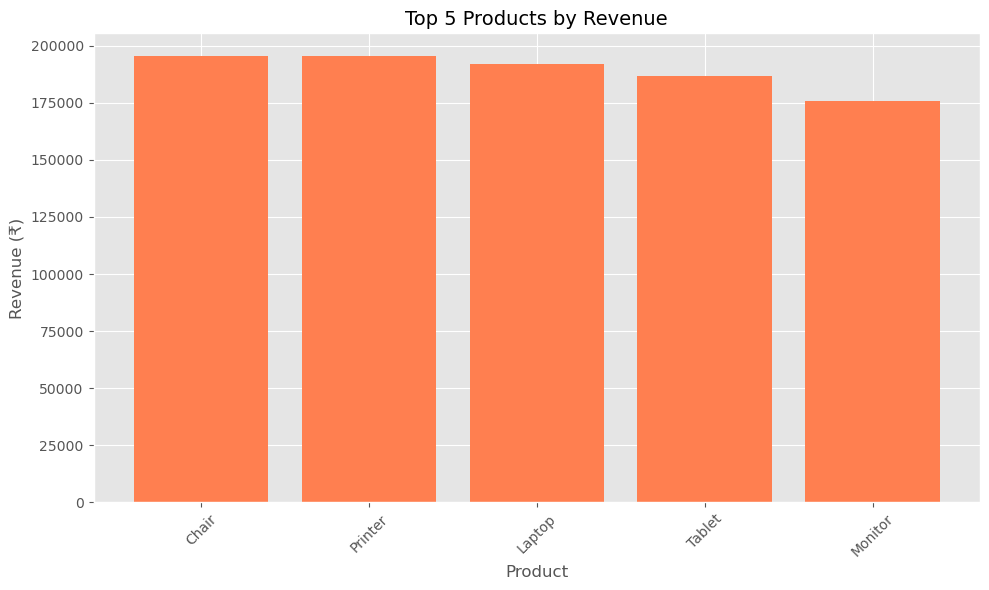

✅ Saved: visualizations/top_products_revenue.png


In [8]:
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.bar(product_rev.index, product_rev.values, color='coral')
plt.title('Top 5 Products by Revenue', fontsize=14)
plt.xlabel('Product')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/top_products_revenue.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/top_products_revenue.png")

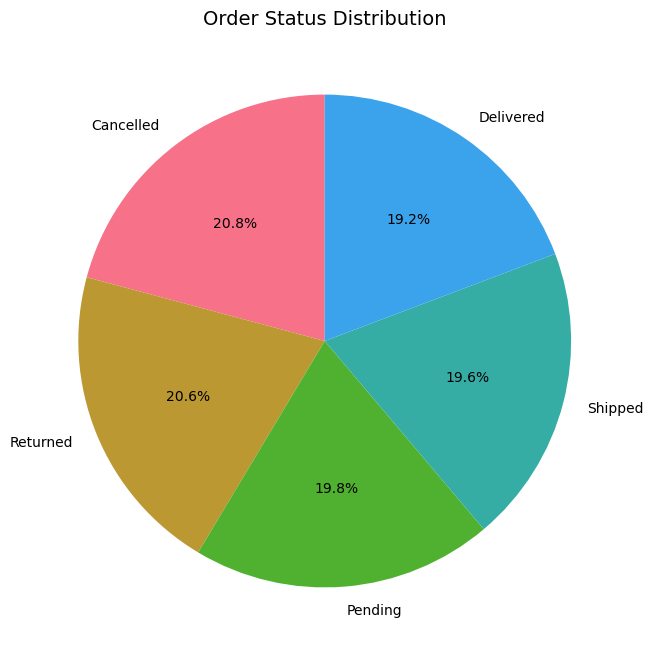

✅ Saved: visualizations/order_status.png


In [9]:
status = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(status.values, labels=status.index, autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution', fontsize=14)
plt.savefig('visualizations/order_status.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/order_status.png")

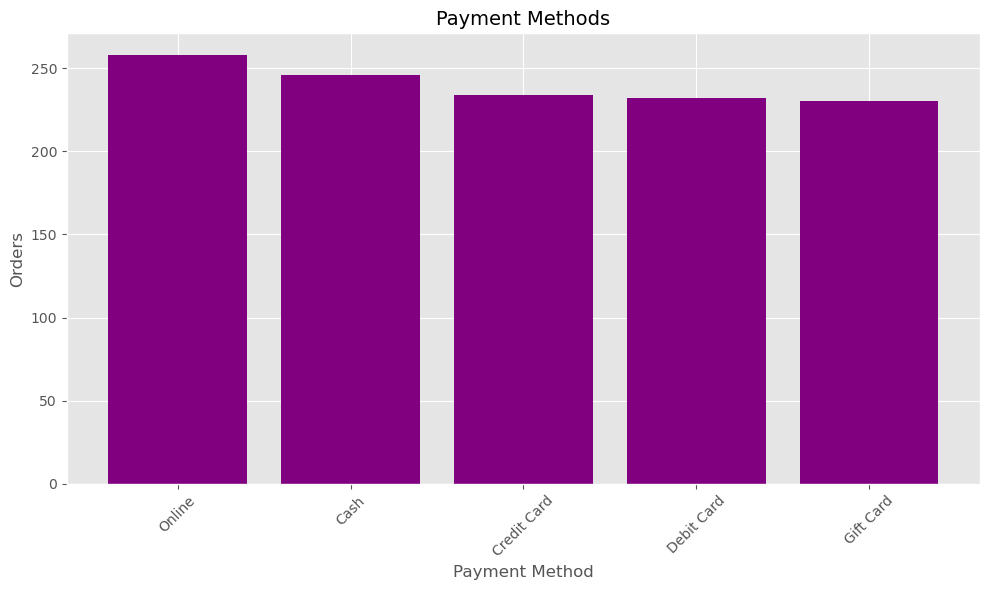

✅ Saved: visualizations/payment_methods.png


In [10]:
payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(payment.index, payment.values, color='purple')
plt.title('Payment Methods', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/payment_methods.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/payment_methods.png")

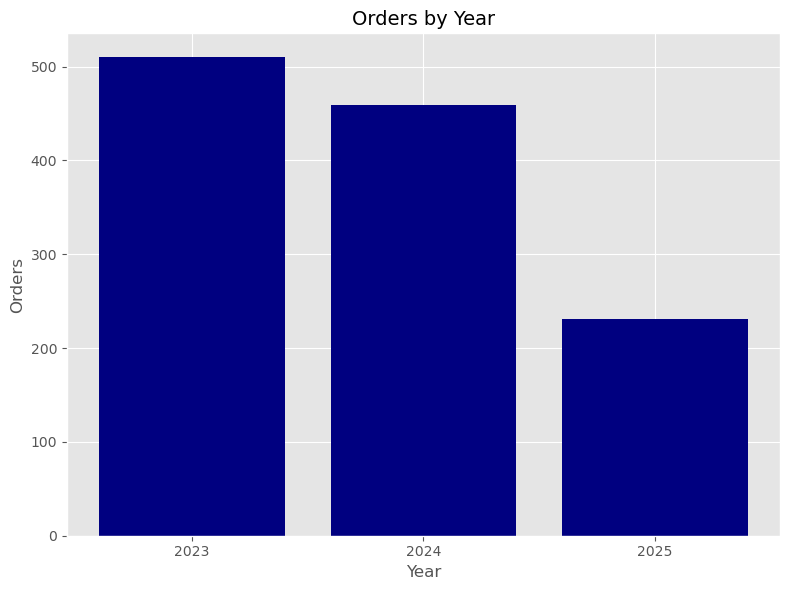

✅ Saved: visualizations/orders_by_year.png


In [11]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(yearly.index.astype(str), yearly.values, color='navy')
plt.title('Orders by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Orders')
plt.tight_layout()
plt.savefig('visualizations/orders_by_year.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/orders_by_year.png")

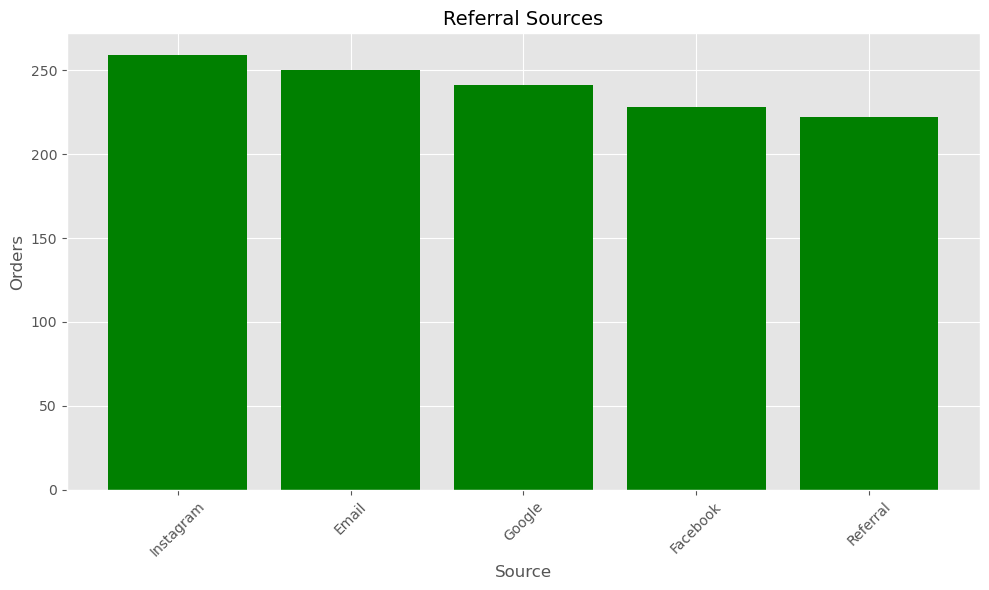

✅ Saved: visualizations/referral_sources.png


In [12]:
referral = df['ReferralSource'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(referral.index, referral.values, color='green')
plt.title('Referral Sources', fontsize=14)
plt.xlabel('Source')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/referral_sources.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/referral_sources.png")

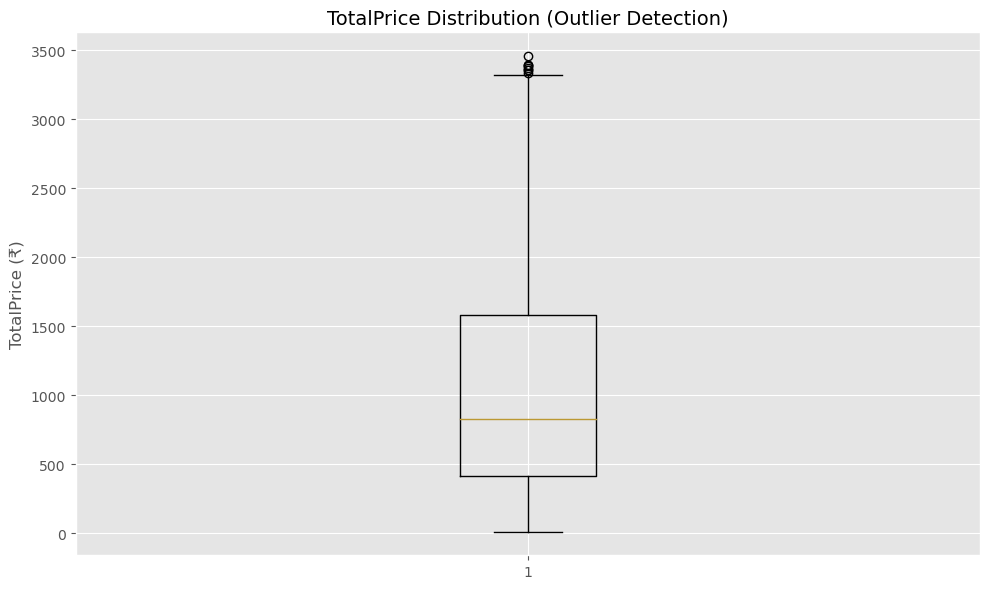

⚠️ Outliers detected: 8 orders
✅ Saved: visualizations/outliers.png


In [13]:
plt.figure(figsize=(10,6))
plt.boxplot(df['TotalPrice'])
plt.title('TotalPrice Distribution (Outlier Detection)', fontsize=14)
plt.ylabel('TotalPrice (₹)')
plt.tight_layout()
plt.savefig('visualizations/outliers.png', dpi=300)
plt.show()

# Count outliers
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(f"⚠️ Outliers detected: {len(outliers)} orders")
print("✅ Saved: visualizations/outliers.png")

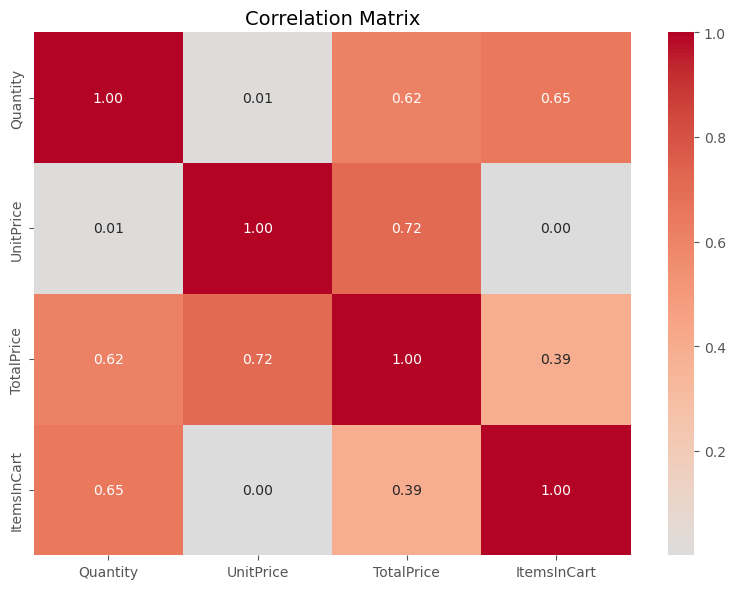

✅ Saved: visualizations/correlation.png


In [14]:
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('visualizations/correlation.png', dpi=300)
plt.show()
print("✅ Saved: visualizations/correlation.png")

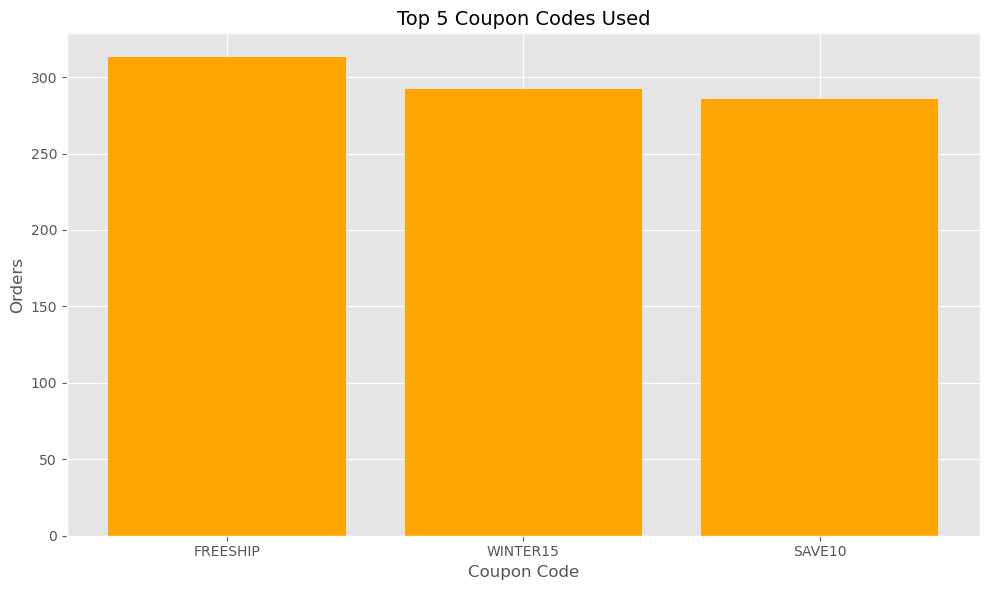

✅ Saved: visualizations/top_coupons.png


In [15]:
coupon_counts = df[df['CouponCode'] != 'No Coupon']['CouponCode'].value_counts().head(5)

if len(coupon_counts) > 0:
    plt.figure(figsize=(10,6))
    plt.bar(coupon_counts.index, coupon_counts.values, color='orange')
    plt.title('Top 5 Coupon Codes Used', fontsize=14)
    plt.xlabel('Coupon Code')
    plt.ylabel('Orders')
    plt.tight_layout()
    plt.savefig('visualizations/top_coupons.png', dpi=300)
    plt.show()
    print("✅ Saved: visualizations/top_coupons.png")
else:
    print("⚠️ No coupon codes found")

In [19]:
print("="*60)
print("✅ PROJECT 2 - EDA COMPLETED!")
print("="*60)


print("\n📊 QUICK INSIGHTS:")
print(f"   • Total Revenue: ₹{total_revenue:,.2f}")
print(f"   • Best Selling Product: {product_qty.index[0]} ({product_qty.values[0]} units)")
print(f"   • Highest Revenue Product: {product_rev.index[0]}")
print(f"   • Most Common Status: {status.index[0]} ({status.values[0]} orders)")
print(f"   • Most Popular Payment: {payment.index[0]}")
print(f"   • Busiest Year: {yearly.idxmax()} ({yearly.max()} orders)")
print(f"   • Top Referral Source: {referral.index[0]}")
print(f"   • Outliers in TotalPrice: {len(outliers)} orders")



✅ PROJECT 2 - EDA COMPLETED!

📊 QUICK INSIGHTS:
   • Total Revenue: ₹1,264,761.96
   • Best Selling Product: Chair (562 units)
   • Highest Revenue Product: Chair
   • Most Common Status: Cancelled (250 orders)
   • Most Popular Payment: Online
   • Busiest Year: 2023 (510 orders)
   • Top Referral Source: Instagram
   • Outliers in TotalPrice: 8 orders
